In [25]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import classification_report ,confusion_matrix , accuracy_score
import pandas as pd
import numpy as np

In [4]:
dataset = pd.read_csv("BankNote_Authentication.csv")
print(dataset)

      variance  skewness  curtosis  entropy  class
0      3.62160   8.66610   -2.8073 -0.44699      0
1      4.54590   8.16740   -2.4586 -1.46210      0
2      3.86600  -2.63830    1.9242  0.10645      0
3      3.45660   9.52280   -4.0112 -3.59440      0
4      0.32924  -4.45520    4.5718 -0.98880      0
...        ...       ...       ...      ...    ...
1367   0.40614   1.34920   -1.4501 -0.55949      1
1368  -1.38870  -4.87730    6.4774  0.34179      1
1369  -3.75030 -13.45860   17.5932 -2.77710      1
1370  -3.56370  -8.38270   12.3930 -1.28230      1
1371  -2.54190  -0.65804    2.6842  1.19520      1

[1372 rows x 5 columns]


In [6]:
x = dataset.drop('class' , axis = 1)
y = dataset['class']

x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2)

[Text(0.5071428571428571, 0.9375, 'x[0] <= 0.297\ngini = 0.495\nsamples = 1097\nvalue = [605, 492]'),
 Text(0.3392857142857143, 0.8125, 'x[1] <= 7.509\ngini = 0.309\nsamples = 530\nvalue = [101, 429]'),
 Text(0.4232142857142857, 0.875, 'True  '),
 Text(0.2357142857142857, 0.6875, 'x[0] <= -0.459\ngini = 0.133\nsamples = 445\nvalue = [32, 413]'),
 Text(0.11428571428571428, 0.5625, 'x[2] <= 6.216\ngini = 0.072\nsamples = 374\nvalue = [14.0, 360.0]'),
 Text(0.05714285714285714, 0.4375, 'x[1] <= 7.293\ngini = 0.008\nsamples = 259\nvalue = [1, 258]'),
 Text(0.02857142857142857, 0.3125, 'gini = 0.0\nsamples = 256\nvalue = [0, 256]'),
 Text(0.08571428571428572, 0.3125, 'x[3] <= -4.115\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.05714285714285714, 0.1875, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.11428571428571428, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.17142857142857143, 0.4375, 'x[1] <= -4.675\ngini = 0.201\nsamples = 115\nvalue = [13, 102]'),
 Text(0

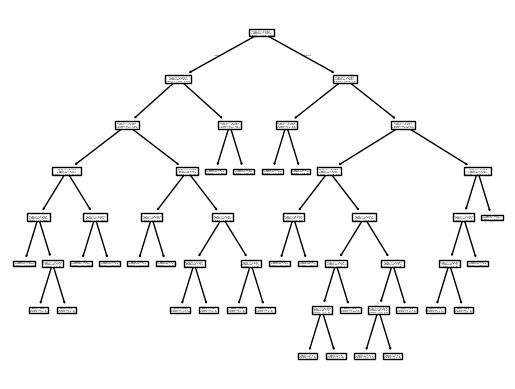

In [26]:
model = DecisionTreeClassifier()
model.fit(x_train , y_train)
y_pred = model.predict(x_test)
plot_tree(model)

In [16]:
# validating = pd.DataFrame({'Actual_y_test' : y_test.squeeze() , 'Predicted_y_pred' : y_pred.squeeze()})
# print(validating)

validating = x_test.copy()

validating['Actual_y_test'] = y_test.squeeze()
validating['Predicted_y_pred'] = y_pred.squeeze()

pd.set_option('display.max_rows' , 500)
pd.set_option('display.max_columns' , 500)
pd.set_option('display.width' , 500)
print(validating)

      variance   skewness   curtosis   entropy  Actual_y_test  Predicted_y_pred
38    4.567900   3.192900  -2.105500  0.296530              0                 0
723   0.748410   7.275600   1.150400 -0.538800              0                 0
203   4.175700  10.261500  -3.855200 -4.305600              0                 0
1104 -3.019300   1.777500   0.737450 -0.453460              1                 1
775  -0.365060   2.892800  -3.646100 -3.060300              1                 1
1156  0.967080   3.842600  -4.931400 -4.132300              1                 1
602   2.783100  10.979600  -3.557000 -4.403900              0                 0
503   4.929400   0.277270   0.207920  0.336620              0                 0
261   3.155700   2.890800   0.596930  0.798250              0                 0
831  -0.394160  -0.020702  -0.066267 -0.446990              1                 1
1213 -2.620000  -6.855500   6.216900 -0.622850              1                 1
246   1.647200   0.482130   4.744900  1.

In [23]:
print("Confusion Matrix :- \n" , confusion_matrix(y_test , y_pred))
print("Accuracy Score :- \n" , accuracy_score(y_test , y_pred))
print("Classification Report :- \n" , classification_report(y_test , y_pred))

Confusion Matrix :- 
 [[154   3]
 [  4 114]]
Accuracy Score :- 
 0.9745454545454545
Classification Report :- 
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       157
           1       0.97      0.97      0.97       118

    accuracy                           0.97       275
   macro avg       0.97      0.97      0.97       275
weighted avg       0.97      0.97      0.97       275

